<a href="https://colab.research.google.com/github/dhar9571/Retail-Sales-Prediction-ML-Regression/blob/main/Capstone_Project_Retail_Sales_Prediction_ML_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Retail Sales Prediction ML Regression


##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team

# **Project Summary -**

**The project involves developing a machine learning model for regression analysis of the Rossmann drug store's daily sales data. The dataset comprises of information on the sales of the stores for several weeks in different European countries. The goal is to predict the sales for the upcoming six weeks based on various factors like promotions, competition, holidays, seasonality, and location.**


# **GitHub Link -**

profile link: https://github.com/dhar9571

project repository link: https://github.com/dhar9571/Retail-Sales-Prediction-ML-Regression.git

# **Problem Statement**


**The Rossmann drug stores need an accurate sales forecasting model that can help the managers predict their daily sales for the upcoming six weeks. Currently, the sales prediction varies significantly among the individual store managers due to the unique circumstances surrounding each store. The task is to develop a machine learning model that can accurately forecast the sales for the upcoming six weeks, considering various factors like promotions, competition, holidays, seasonality, and location. The model should provide a reliable and accurate prediction of the sales for the stores, enabling better decision-making and resource allocation for the company.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required. 
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits. 
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact? 
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule. 

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import f_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

### Dataset Loading

In [3]:
# Mounting google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load Dataset

rossmann_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AlmaBetter/Capstone Project - Retail Sales Prediction ML Regression/Rossmann Stores Data.csv")
store_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AlmaBetter/Capstone Project - Retail Sales Prediction ML Regression/store.csv")

<ipython-input-4-c3f2ee0203c4>:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  rossmann_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AlmaBetter/Capstone Project - Retail Sales Prediction ML Regression/Rossmann Stores Data.csv")


### Dataset First View

In [5]:
store_data.shape

(1115, 10)

In [6]:
# Dataset First Look

rossmann_data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [7]:
# Dataset First Look

store_data.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
# Merging the dataset

df = pd.merge(rossmann_data, store_data, on="Store",how="left")

### Dataset Rows & Columns count

In [9]:
# Dataset Rows & Columns count

print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 1017209
Number of columns: 18


### Dataset Information

In [10]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

#### Duplicate Values

In [11]:
# Dataset Duplicate Value Count

df.duplicated().sum()

0

#### Missing Values/Null Values

In [12]:
# Missing Values/Null Values Count

df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

<Axes: >

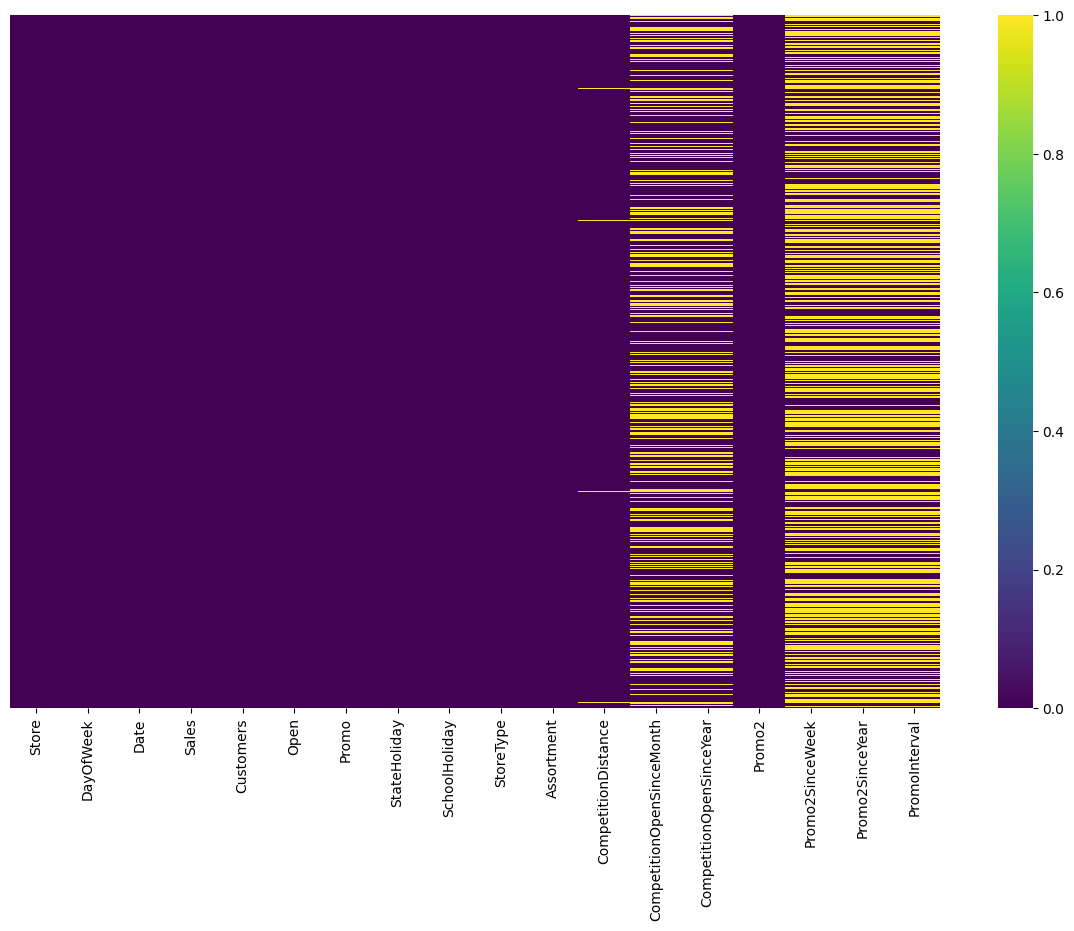

In [13]:
# Visualizing the missing values

# setting up figure size:
plt.figure(figsize=(15, 9))

sns.heatmap(df.isna(),yticklabels=False,cbar=True,cmap='viridis')

**Why did you pick the specific chart?**

Heatmaps allow us to visualize the missing values in the context of the entire DataFrame, which can be useful for identifying patterns and correlations in the missing data.

**What is/are the insight(s) found from the chart?**

I am able to identify that in the entire dataframe, Promo2SinceWeek, Promo2SinceYear and PromoInterval columns have highest and equal number of null values. Besides this, CompetitionOpenSinceMonth and CompetitionOpenSinceYear columns also have a lot of null values. CompetitionDistance column has few null values.

**Will the gained insights help creating a positive business impact?**

Plotting missing values as a heatmap is important for ensuring data quality, cleaning the data, gaining insights, and preparing the data for further analysis or modeling.

### What did you know about your dataset?

1. The Dataset was devided into two different dataframes rossmann_data and store_data with common/primary key column "store".

2. The dataset has no duplicate rows.

3. The dataset has 2642 null values in CompetitionDistance column, 323348 null values in CompetitionOpenSinceMonth and CompetitionOpenSinceYear columns and 508031 null values in Promo2SinceWeek, Promo2SinceYear and PromoInterval columns.

4. The dataset has 1017209 rows and 18 columns.

5. Dependent feature name is "Sales".

## ***2. Understanding Your Variables***

In [14]:
# Dataset Columns

df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [15]:
# Dataset Describe

df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


### Variables Description 

####**Store**: the unique identifier.

####**DayOfWeek**: the day of the week).

####**Date**: the date of sales.

####**Sales**: the amount of sales.

####**Customers**: the number of customers in a particular store on a given date.

####**Open**: indicates whether the store was open or closed on a given date.

####**Promo**: indicates whether a store was running a promo on a given date .

####**StateHoliday**: indicates whether a state holiday was on a given date.

####**SchoolHoliday**: indicates whether a school holiday was on a given date.

####**StoreType**: indicates the type of store.

####**Assortment**: indicates the assortment level of the store.

####**CompetitionDistance**: the distance of the store to the nearest competitor store.

####**CompetitionOpenSinceMonth**: the month of the year when the nearest competitor store was opened.

####**CompetitionOpenSinceYear**: the year when the nearest competitor store was opened.

####**Promo2**: indicates whether a store is running a continuous promotion.

####**Promo2SinceWeek**: the calendar week when the store started to run a continuous promotion.

####**Promo2SinceYear**: the year when the store started to run a continuous promotion.

####**PromoInterval**: the interval between the consecutive starts of the continuous promotion.

### Check Unique Values for each variable.

In [29]:
# Check Unique Values for each variable.
df.nunique()

Store                         1115
DayOfWeek                        7
Date                           942
Sales                        21734
Customers                     4086
Open                             2
Promo                            2
StateHoliday                     5
SchoolHoliday                    2
StoreType                        4
Assortment                       3
CompetitionDistance            654
CompetitionOpenSinceMonth       12
CompetitionOpenSinceYear        23
Promo2                           2
Promo2SinceWeek                 24
Promo2SinceYear                  7
PromoInterval                    3
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [23]:
# Write your code to make your dataset analysis ready.

# Setting up to show all the columns
pd.set_option('display.max_columns',None)

In [ ]:
# Creating Date, Month and Year columns using Date columns:

df["Day"] = df["Date"].apply(lambda x: x.split("-")[2])
df["Month"] = df["Date"].apply(lambda x: x.split("-")[1])
df["Year"] = df["Date"].apply(lambda x: x.split("-")[0])

In [27]:
# Removing Date column as it is not required now:

df.drop("Date",axis=1,inplace=True)

In [45]:
# Checking StateHoliday column's unique values

df["StateHoliday"].value_counts()

0    855087
0    131072
a     20260
b      6690
c      4100
Name: StateHoliday, dtype: int64

### What all manipulations have you done and insights you found?

1. The dataset had string type Date column. Therefore, created seperate Day, Month and Year columns.

2. Dropped Date column as have extracted required columns from it.

3. Noticed irregularities in StateHoliday column values which is having 0 value being counted twice when calling value_counts() function.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Correlation HeatMap

<ipython-input-50-8ebd7c10d177>:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


Text(0.5, 1.0, 'Correlation HeatMap')

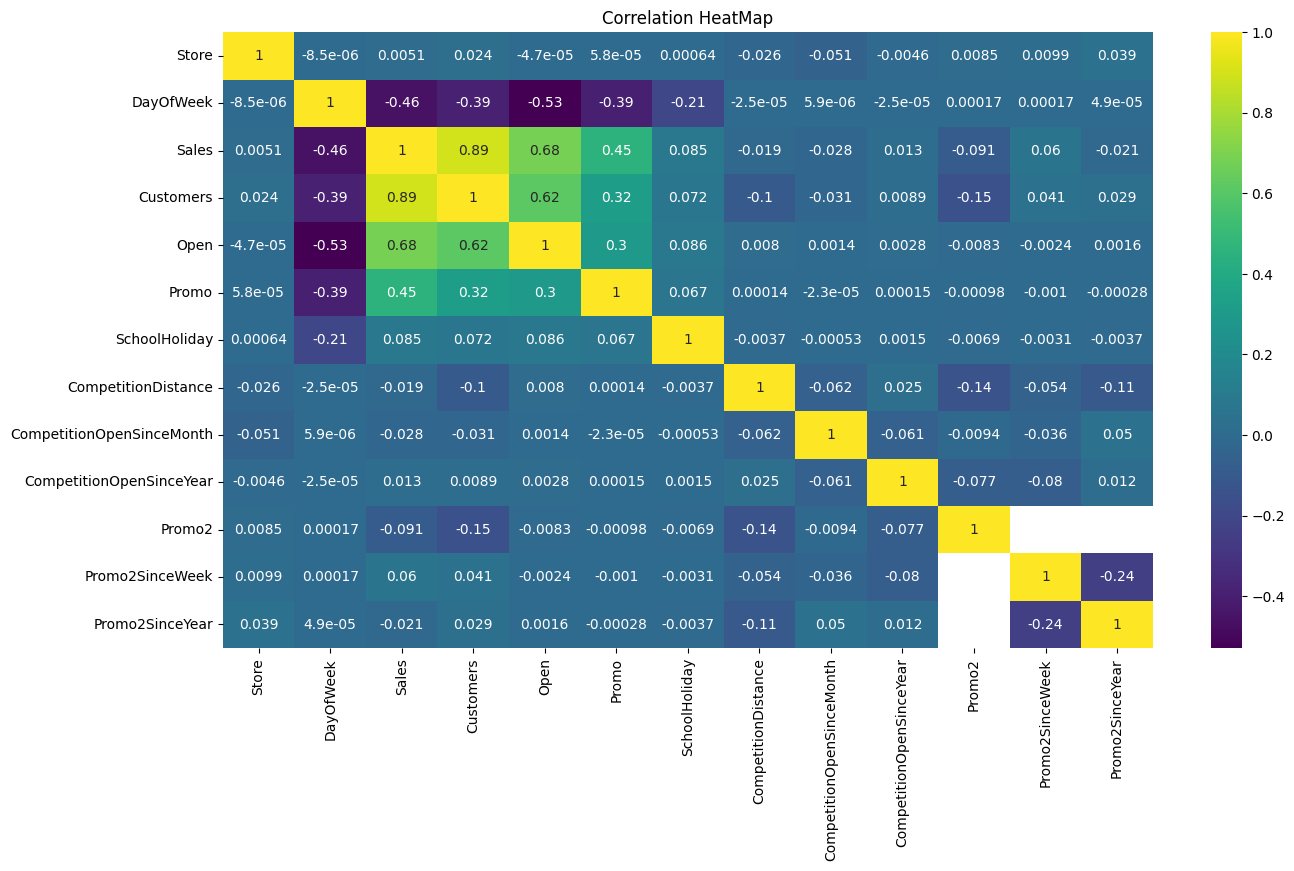

In [50]:
# Chart - 1 Correlation Heatmap visualization code

# Saving correlation in a variable using corr() function

corr = df.corr()

# Setting up larger plot size

plt.figure(figsize=(15,8))

# Plotting Heatmap

sns.heatmap(corr,cbar=True, annot=True,cmap='viridis')

# Setting title

plt.title("Correlation HeatMap")

##### 1. Why did you pick the specific chart?

Heatmaps use colors to represent values, making it easy to visually identify areas of high and low correlation. The use of a color scale allows us to quickly spot patterns and trends in the data.

##### 2. What is/are the insight(s) found from the chart?

1. Customers and Open columns have strong positive correlation with Sales column.
2. Open and DayOfWeek columns are negatively correlated with each other.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

The columns have positive correlation, it means the increase in one variable will also increase other variable. However, negative correlation means increase in one variable will lead to decrease in other variable. This relation helps the business to understand the important factors affecting the Sales(dependent feature).

#### Chart - 2 - Month wise Average Sales (Bivariate)

Text(0.5, 1.0, 'Month wise Average Sales')

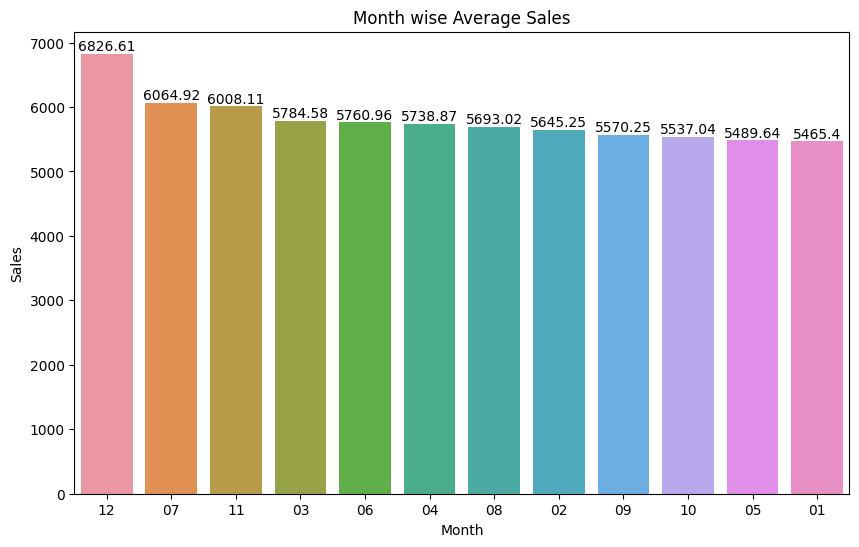

In [62]:
# Chart - 2 visualization code

# Setting plot size

plt.figure(figsize=(10,6))

# Creating a dataframe having Sorted Months and their respective sales

month_sales = df.groupby("Month")["Sales"].mean().reset_index().sort_values(by="Sales",ascending=False)

# Plotting bargraph:

# Creating instance and for loop to show respective values on the bars:

ms = sns.barplot(x=month_sales["Month"],y=month_sales["Sales"])

for value in ms.containers:
  ms.bar_label(value)

# Setting Title

plt.title("Month wise Average Sales")

##### 1. Why did you pick the specific chart?

Bar chart allows for easy comparison among different categories, making it possible to see patterns, trends, and relationships.

##### 2. What is/are the insight(s) found from the chart?

1. December Month is having the most average Sales.
2. Remaining all months do not have significant difference in sales.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

December (last month) of the year has the highest average sales indicating that this month has high opportunites of improving sales.

#### Chart - 3 - Year wise Average Sales (Bivariate)

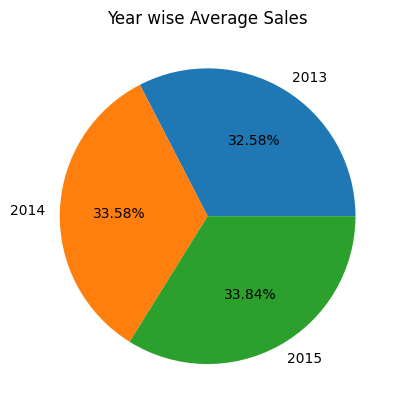

In [66]:
# Chart - 3 visualization code

# Creating a seperate dataframe containing year wise grouped average sales

year_sales = df.groupby("Year")["Sales"].mean().reset_index()

# Creating Pie Chart

plt.pie(x = year_sales["Sales"], data = year_sales,labels=year_sales["Year"],autopct="%.2f%%")

# setting up plot title
plt.title("Year wise Average Sales")
plt.show()

##### 1. Why did you pick the specific chart?

Pie charts are simple and intuitive, making them easy to understand even for people who are not familiar with data visualization.

##### 2. What is/are the insight(s) found from the chart?

Year 2015 has the highest average sales. All the years do not have significant difference in Average Sale.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

As the average sales for all the years are almost same, we can conclude that there was no specific aspect or factor which positively or negatively impacted the sales.

#### Chart - 4 - Top 10 Days with Highest Average Sales (Bivariate)

Text(0.5, 1.0, 'Top 10 Days')

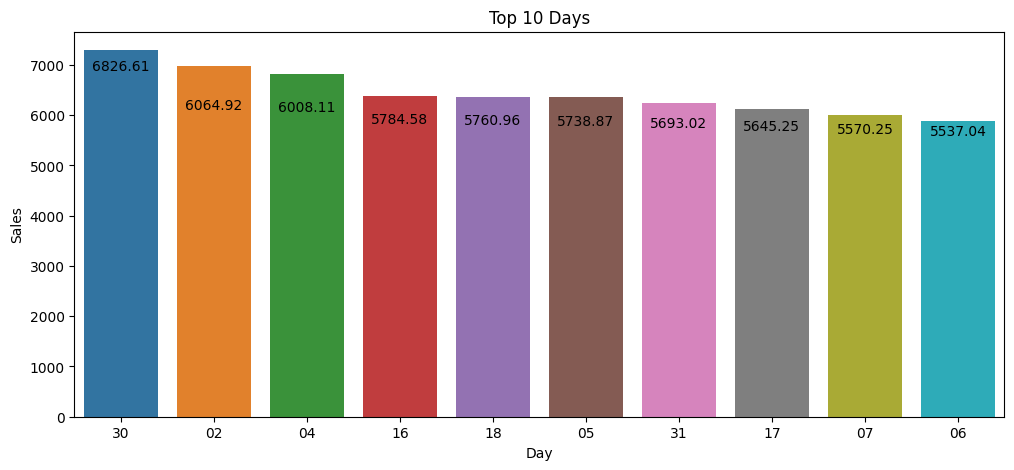

In [73]:
# Chart - 4 visualization code

# Setting up plot size

plt.figure(figsize=(12,5))

# Creating a seperate dataframe which will contain Day wise grouped average sales

day_sales = df.groupby("Day")["Sales"].mean().reset_index().sort_values(by="Sales",ascending=False)

# Plotting bargraph:

# Creating instance and for loop to show respective values on the bars:

ds = sns.barplot(x=day_sales["Day"][:10],y=day_sales["Sales"][:10])

for value in ms.containers:
  ds.bar_label(value)

# Setting Plot Title:

plt.title("Top 10 Days")

##### 1. Why did you pick the specific chart?

Bar chart allows for easy comparison among different categories, making it possible to see patterns, trends, and relationships.

##### 2. What is/are the insight(s) found from the chart?

1. Last day of the month is having the highest average sales.
2. 2nd and 4th days of the month are also having high sales.
3. Remaining days do not have much difference in terms of average sales.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Knowing specific days of the months having highest sales is crucial. So that, offers and discounts can be offered accordingly.

#### Chart - 5 - Distribution of CompetitionDistance Data (Univariate) 

Text(0.5, 1.0, 'Distribution of CompetitionDistance')

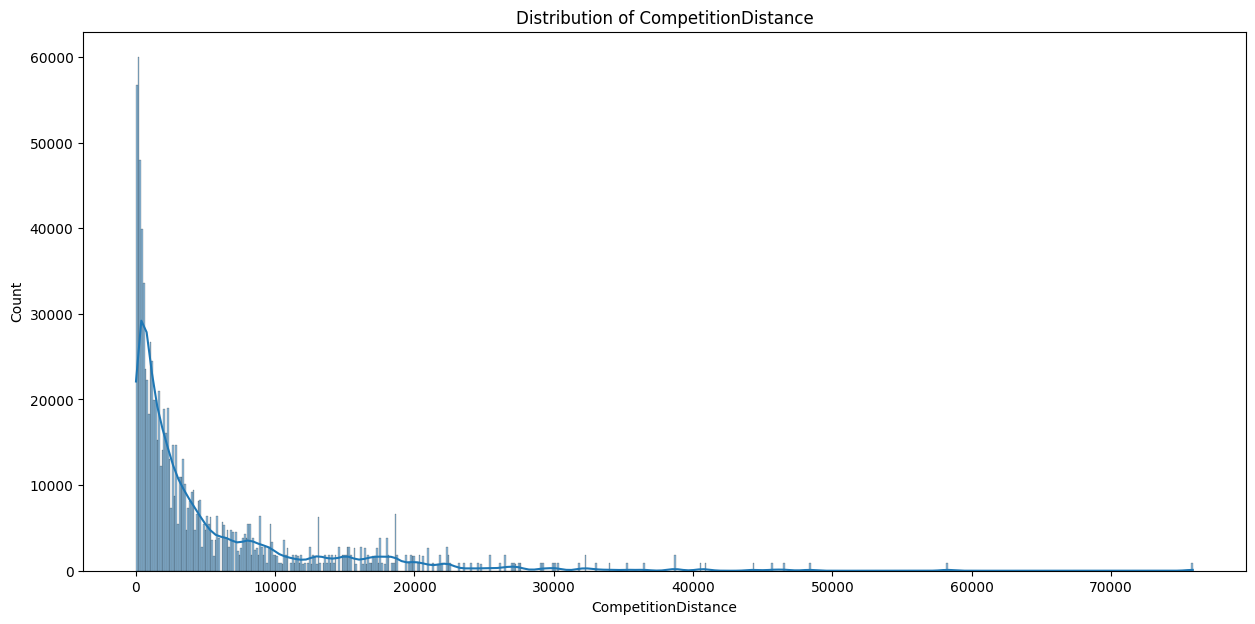

In [103]:
# Chart - 5 visualization code

# Setting plot size

plt.figure(figsize=(15,7))

# Plotting the chart

sns.histplot(df['CompetitionDistance'],kde=True)

# Setting Title

plt.title("Distribution of CompetitionDistance")

##### 1. Why did you pick the specific chart?

Histograms are important for visualizing the distribution of a continuous variable. They provide a visual representation of the data and allow us to identify patterns and trends in the data.

##### 2. What is/are the insight(s) found from the chart?

1. Most of the stores in the dataset are located within a distance of 0 to 10000 meters from their nearest competitor

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

This information can be useful for retailers to understand their competition and plan their business strategies accordingly. It can also indicate the level of saturation in a particular area with regards to similar businesses.

#### Chart - 6 - Weekday wise Frequency (Univariate)

Text(0.5, 1.0, 'Weekday Frequency')

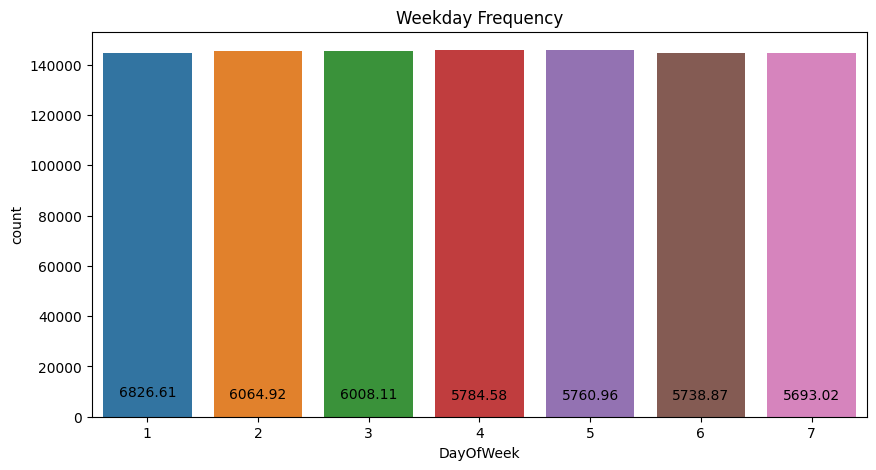

In [74]:
# Chart - 6 visualization code

# Setting up Plot Size

plt.figure(figsize=(10,5))

# Plotting bargraph:

# Creating instance and for loop to show respective values of the bars:

wd = sns.countplot(x=df["DayOfWeek"])

for value in ms.containers:
  wd.bar_label(value)

# Setting Title

plt.title("Weekday Frequency")

##### 1. Why did you pick the specific chart?

Countplots can be used to quickly compare the frequency of each category in the variable. This can be useful for identifying which categories are more common or less common in the data.

##### 2. What is/are the insight(s) found from the chart?

All of the Weedays are not having much or significant difference in terms of total counts.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Having information on the specific weekday is crucial so more and more customers can be attracted by offerring different perks and offers.

#### Chart - 7 - Month Wise Total Customers (Bivariate)

Text(0.5, 1.0, 'Month Wise Total Customers')

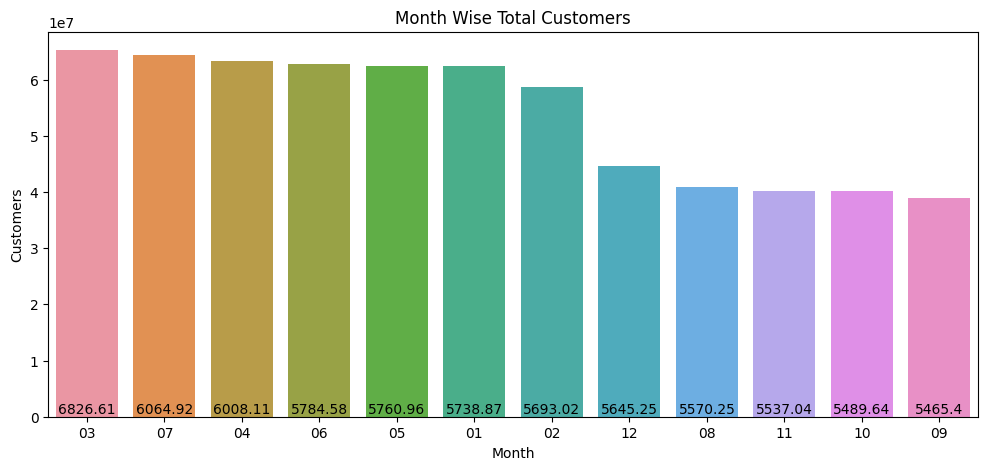

In [78]:
# Chart - 7 visualization code

# Setting up plot size

plt.figure(figsize=(12,5))

# Creating a seperate dataframe which will contain month wise total customer count

month_customer = df.groupby("Month")["Customers"].sum().reset_index().sort_values(by="Customers",ascending=False)

# Plotting bargraph:

# Creating instance and for loop to show respective values on the bars:

mc = sns.barplot(x=month_customer["Month"],y = month_customer["Customers"])

for value in ms.containers:
  mc.bar_label(value)

# Setting Plot Title:

plt.title("Month Wise Total Customers")

##### 1. Why did you pick the specific chart?

Bar Plots allows for easy visualization of categorical data. By showing the count of each category, it can help identify patterns or trends in the data.

##### 2. What is/are the insight(s) found from the chart?

1. 3rd Month has the highest total customers whereas 9th Month has lowest total customers.
2. It is surprising that despite 12th Month having highest Average Sales, is having very low total customers compared to other months.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Having information on months having different customer counts is important to have a glance on data that highest customer counts does not alwasy mean highest sales.

#### Chart - 8 - Store and Month wise Average Sales (Multivariate)

Text(0.5, 1.0, 'Store and Month wise Average Sales')

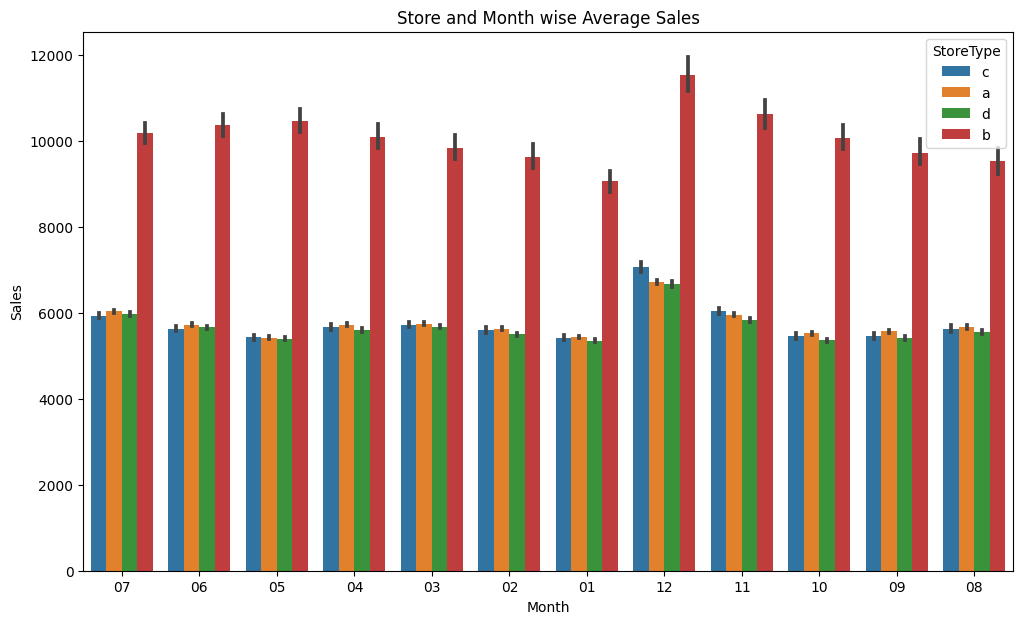

In [85]:
# Chart - 8 visualization code

# Setting up plot size

plt.figure(figsize=(12,7))

# Plotting graph

sns.barplot(x=df["Month"],y=df["Sales"],hue=df["StoreType"])

# Setting Title

plt.title("Store and Month wise Average Sales")

##### 1. Why did you pick the specific chart?

Bar chart allows for easy comparison among different categories, making it possible to see patterns, trends, and relationships.

##### 2. What is/are the insight(s) found from the chart?

1. In each of the month, Storetype b is having the highest average Sales.
2. Remaining StoreTypes are not having much difference in average Sales.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Analyzing Sales with respect to both StoreType and Month can help identify the effectiveness of different marketing strategies used by different types of stores.

#### Chart - 9 - PromotionStatus wise Trend of Customers over ompetitionDistance (Multivariate)

Text(0.5, 1.0, 'PromotionStatus wise Customers over CompetitionDistance')

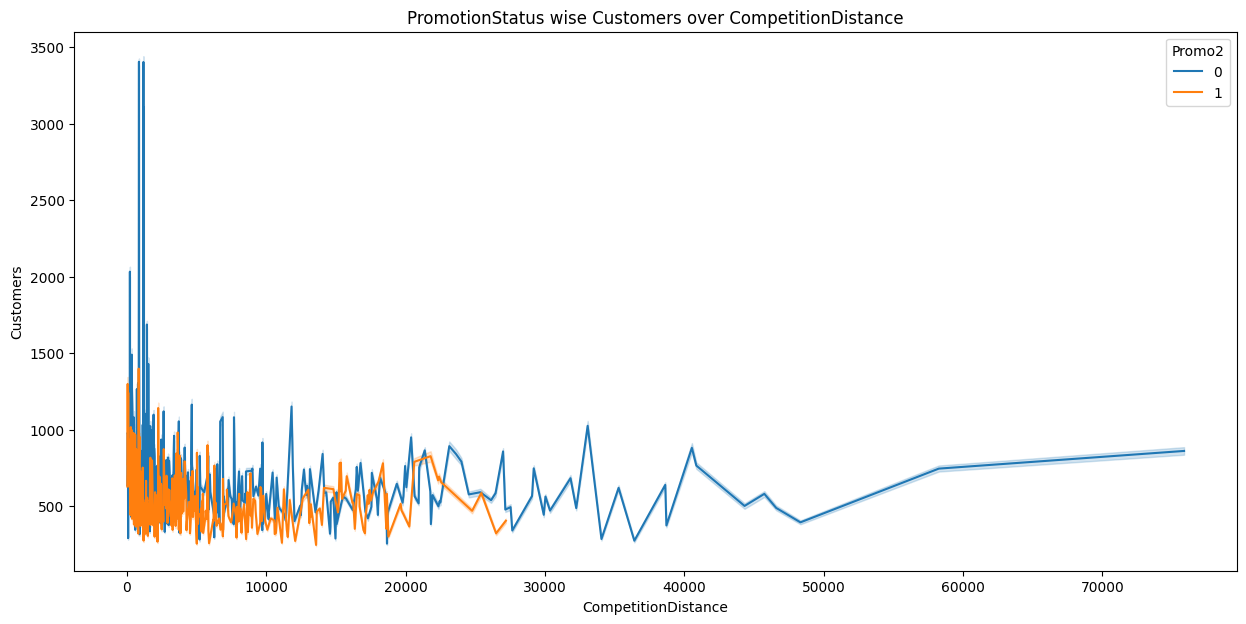

In [92]:
# Chart - 9 visualization code

#Setting plotsize

plt.figure(figsize=(15,7))

sns.lineplot(x=df["CompetitionDistance"], y=df["Customers"], hue=df["Promo2"])

# Setting title

plt.title("PromotionStatus wise Customers over CompetitionDistance")

##### 1. Why did you pick the specific chart?

Line plots allow us to compare multiple data series on the same graph, which can be useful for identifying similarities or differences between the data.

##### 2. What is/are the insight(s) found from the chart?

1. By the above plot, we can see that when the competitor distance is less, number of customers are high. Incease in competitor store distance is leading to less number of customers.

2. When promotions are on, the count of customers are very high compared to no promotions.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

By examining the number of customers who visit a store during a promotion period versus a non-promotion period, we can determine the effectiveness of the promotion in attracting customers. Additionally, by looking at how the distance to the nearest competitor affects customer behavior during a promotion period versus a non-promotion period, we can determine the impact of competition on customer behavior.



#### Chart - 10 - Assortment and Storetype wise Average Sales (Multivariate)

Text(0.5, 1.0, 'Assortment and Storetype wise Average Sales')

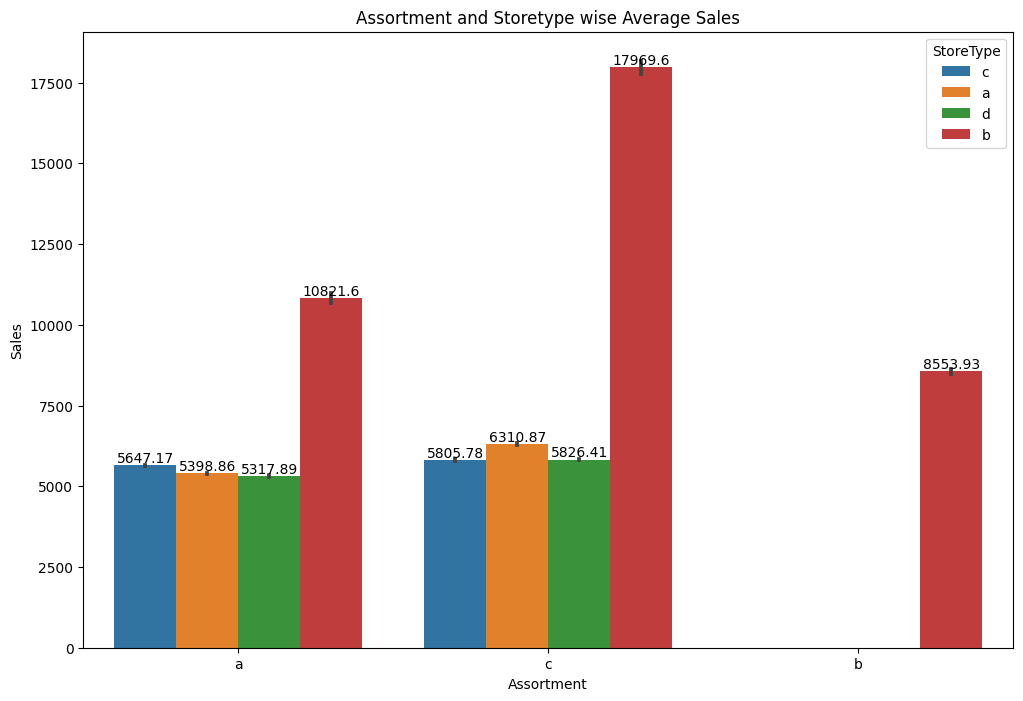

In [98]:
# Chart - 10 visualization code

# Setting plot size

plt.figure(figsize=(12,8))

# Plotting

ass = sns.barplot(x=df["Assortment"],y=df["Sales"],hue=df["StoreType"])

for item in ass.containers:
  ass.bar_label(item)

# Setting title

plt.title("Assortment and Storetype wise Average Sales")

##### 1. Why did you pick the specific chart?

Bar chart allows for easy comparison among different categories, making it possible to see patterns, trends, and relationships.

##### 2. What is/are the insight(s) found from the chart?

1. Assortment b only has one StoreType b which is having the highest sales for all the assortment types.
2. Assortment a and c have multiple StoreTypes.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

The assortment and store type can both impact the product offerings and customer experience of a store, which in turn can affect sales. By analyzing the average sales for each combination of assortment and store type, we can determine which combination is most effective in driving sales. This information can be used to optimize product offerings, store layouts, and marketing strategies to increase sales.

#### Chart - 11 - Correlation Customers vs Sales (Bivariate)

Text(0.5, 1.0, 'Correlation Customers vs Sales')

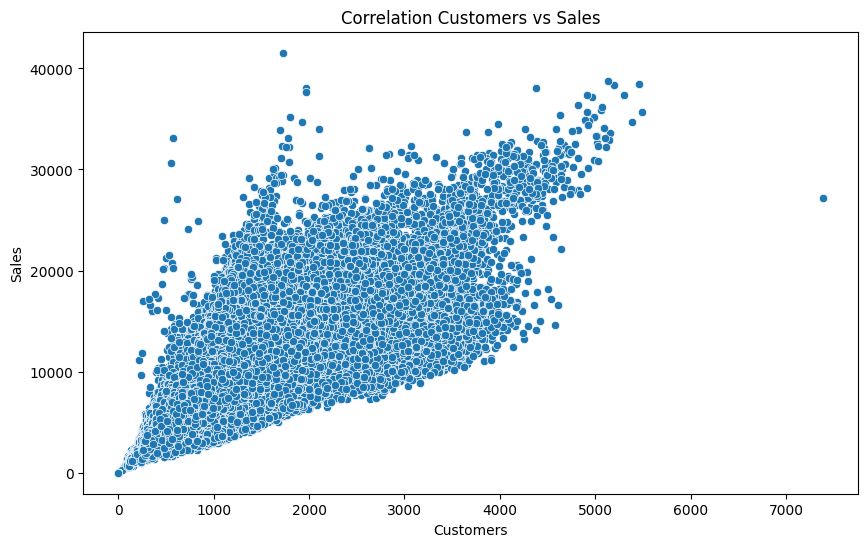

In [111]:
# Chart - 11 visualization code

# Setting plot size

plt.figure(figsize=(10,6))

# Creating plot

sns.scatterplot(x=df["Customers"],y=df["Sales"])

# Setting up title

plt.title("Correlation Customers vs Sales")

##### 1. Why did you pick the specific chart?

Scatter plots are important for visualizing the relationship between two continuous variables. They provide a quick and easy way to see whether there is a correlation or pattern between the two variables.

##### 2. What is/are the insight(s) found from the chart?

1. Customers and Sales are positively correlated with each other.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

If there is a positive correlation between the number of customers and sales, it suggests that as the number of customers increase, the sales also increase. This can be helpful for businesses to understand how to increase their sales by attracting more customers.

#### Chart - 12 - Sales Outliers Detection (Univariate)

Text(0.5, 1.0, 'Sales Outliers')

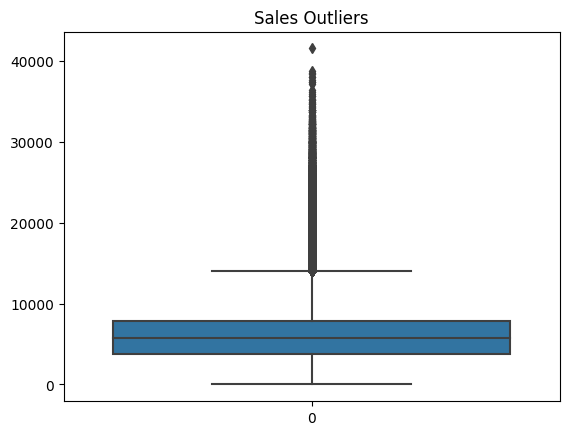

In [112]:
# Chart - 12 visualization code

sns.boxplot(df["Sales"])

# Setting title

plt.title("Sales Outliers")

##### 1. Why did you pick the specific chart?

Boxplot can help us identify outliers in the data that may be due to measurement errors, data entry errors, or genuine extreme values. These outliers can be examined more closely to determine their cause and to decide whether they should be included or excluded in further analysis.

##### 2. What is/are the insight(s) found from the chart?

Sales column has a lot of outliers which may affect the overall business.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Identifying and addressing outliers can help businesses make more informed decisions, improve forecasting accuracy, and ultimately improve overall performance. It can also help businesses identify potential risks and opportunities that may have otherwise gone unnoticed.

#### Chart - 13 - Customers Outliers Detection (Univariate)

Text(0.5, 1.0, 'Customers Outliers')

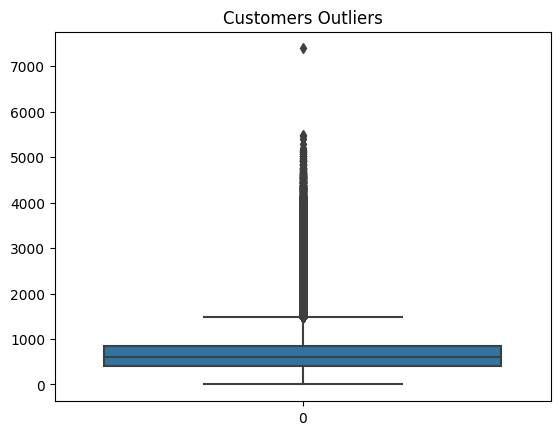

In [113]:
# Chart - 13 visualization code

sns.boxplot(df["Customers"])

# Setting title

plt.title("Customers Outliers")

##### 1. Why did you pick the specific chart?

Boxplot can help us identify outliers in the data that may be due to measurement errors, data entry errors, or genuine extreme values. These outliers can be examined more closely to determine their cause and to decide whether they should be included or excluded in further analysis.

##### 2. What is/are the insight(s) found from the chart?

Sales column has a lot of outliers which may affect the overall business.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Identifying and addressing outliers can help businesses make more informed decisions, improve forecasting accuracy, and ultimately improve overall performance. It can also help businesses identify potential risks and opportunities that may have otherwise gone unnoticed.

#### Chart - 14 - CompetitionDistance Outliers Detection (Univariate)

Text(0.5, 1.0, 'CompetitionDistance Outliers')

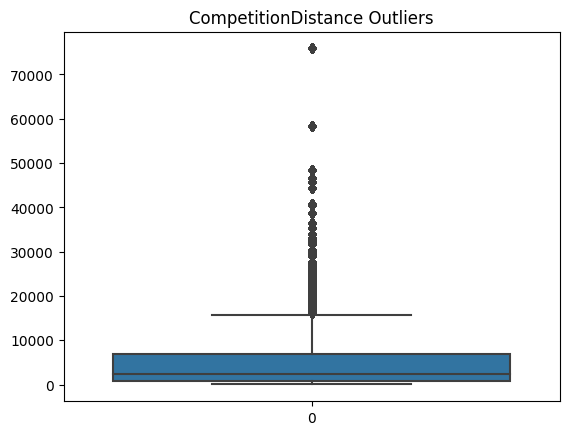

In [115]:
# Chart - 14 visualization code

sns.boxplot(df["CompetitionDistance"])

# Setting title

plt.title("CompetitionDistance Outliers")

##### 1. Why did you pick the specific chart?

Boxplot can help us identify outliers in the data that may be due to measurement errors, data entry errors, or genuine extreme values. These outliers can be examined more closely to determine their cause and to decide whether they should be included or excluded in further analysis.

##### 2. What is/are the insight(s) found from the chart?

Sales column has a lot of outliers which may affect the overall business.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Identifying and addressing outliers can help businesses make more informed decisions, improve forecasting accuracy, and ultimately improve overall performance. It can also help businesses identify potential risks and opportunities that may have otherwise gone unnoticed.

#### Chart - 15 - Pair Plot 

In [ ]:
# Pair Plot visualization code

sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Pairplot is an important tool in exploratory data analysis (EDA) because it allows for the visualization of pairwise relationships between multiple variables in a dataset. By creating scatterplots of every possible combination of two variables in a dataset, pairplot can help identify trends, patterns, and potential relationships between variables. It can also be used to detect outliers and to identify potential areas of interest for further analysis.

##### 2. What is/are the insight(s) found from the chart?

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing 
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why? 

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***